In [1]:
# Imports & paths
from pathlib import Path
import json, math
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from PIL import Image

# Base folder containing multiple experiments
SCHEDULE_ROOT = Path('../results/2025-12-11_02-40-51_schedule_26exp').resolve()
EXPERIMENT_DIRS = [p for p in sorted(SCHEDULE_ROOT.iterdir()) if p.is_dir()]

# Ground-truth masks root (used for computing segmentation metrics when metrics_per_frame.json is absent)
GT_MASK_ROOT = Path('../dataset/超音波檔案-20251126T083302Z-1-001/seg_masks').resolve()

# Per-experiment detection metrics roots
DET_METRICS_ROOTS = {p.name: p / 'test' / 'detection' / 'metrics' for p in EXPERIMENT_DIRS}

# Per-experiment segmentation roots: find predictions/*/YOLOv11 (model subdir varies: unetpp/medsam/automask/etc.)
SEG_ROOTS = {}
for p in EXPERIMENT_DIRS:
    pred_base = p / 'test' / 'segmentation' / 'predictions'
    seg_root = None
    if pred_base.exists():
        # search one level under predictions for the model folder, then YOLOv11
        for model_dir in sorted(pred_base.iterdir()):
            candidate = model_dir / 'YOLOv11'
            if candidate.exists():
                seg_root = candidate
                break
        # fallback: if predictions/YOLOv11 exists directly
        direct = pred_base / 'YOLOv11'
        if seg_root is None and direct.exists():
            seg_root = direct
    SEG_ROOTS[p.name] = seg_root if seg_root else pred_base / 'YOLOv11'  # keep path even if missing for later check

def mask_centroid(mask_path: Path):
    arr = np.array(Image.open(mask_path).convert('L'))
    ys, xs = np.nonzero(arr)
    if len(xs) == 0:
        return None
    return float(xs.mean()), float(ys.mean())

print('Schedule root:', SCHEDULE_ROOT)
print('Experiments found:', len(EXPERIMENT_DIRS))
for name, root in list(SEG_ROOTS.items())[:3]:
    print(' -', name, '| seg root exists:', root.exists())

Schedule root: C:\Users\User\Desktop\code\Traking\results\2025-12-11_02-40-51_schedule_26exp
Experiments found: 25
 - 2025-12-11_02-40-51_none_nnunet | seg root exists: True
 - 2025-12-11_03-05-53_none_unetpp | seg root exists: True
 - 2025-12-11_03-27-52_none_medsam | seg root exists: True


In [2]:
# Helpers to load detection per-frame metrics (JSON preferred, CSV fallback) across experiments
def load_json(path: Path):
    try:
        with path.open('r', encoding='utf-8') as fh:
            return json.load(fh)
    except Exception:
        return None


def load_detection_per_frame(metrics_roots: dict) -> pd.DataFrame:
    records = []
    for exp_name, metrics_root in metrics_roots.items():
        if not metrics_root.exists():
            continue
        for video_dir in sorted(metrics_root.iterdir()):
            if not video_dir.is_dir():
                continue
            video = video_dir.name
            json_candidates = sorted(video_dir.glob('*_per_frame.json'))
            per_frame = None
            for cand in json_candidates:
                per_frame = load_json(cand)
                if per_frame:
                    break
            if per_frame:
                for frame_str, vals in per_frame.items():
                    try:
                        fi = int(frame_str)
                    except Exception:
                        continue
                    ce = vals.get('ce')
                    iou = vals.get('iou')
                    records.append({'experiment': exp_name, 'video': video, 'frame': fi, 'det_ce': ce, 'det_iou': iou})
                continue
            # CSV fallback
            csv_candidates = sorted(video_dir.glob('*_per_frame.csv'))
            for csv_path in csv_candidates:
                df_csv = pd.read_csv(csv_path)
                ce_col = None
                for col in df_csv.columns:
                    if str(col).lower() in {'center_error', 'ce'}:
                        ce_col = col
                        break
                if ce_col is None and len(df_csv.columns) >= 3:
                    ce_col = df_csv.columns[2]
                fi_col = df_csv.columns[0]
                iou_col = df_csv.columns[1] if len(df_csv.columns) > 1 else None
                for _, row in df_csv.iterrows():
                    if pd.isna(row.get(fi_col)):
                        continue
                    try:
                        fi = int(row[fi_col])
                    except Exception:
                        continue
                    ce = row.get(ce_col) if ce_col in row else None
                    iou = row.get(iou_col) if (iou_col and iou_col in row) else None
                    records.append({
                        'experiment': exp_name,
                        'video': video,
                        'frame': fi,
                        'det_ce': float(ce) if pd.notna(ce) else None,
                        'det_iou': float(iou) if (iou_col and pd.notna(iou)) else None
                    })
    return pd.DataFrame(records)

# Optional: raw detection metrics (bbox-center vs GT bbox-center); downstream overridden by centroid-based CE
det_df_raw = load_detection_per_frame(DET_METRICS_ROOTS)
det_df_raw.head()

,experiment,video,frame,det_ce,det_iou
0,2025-12-11_02-40-51_none_nnunet,001Grasp,0,3.633866,0.844088
1,2025-12-11_02-40-51_none_nnunet,001Grasp,14,15.207557,0.681328
2,2025-12-11_02-40-51_none_nnunet,001Grasp,29,3.682154,0.860392
3,2025-12-11_02-40-51_none_nnunet,001Grasp,44,4.680964,0.867020
4,2025-12-11_02-40-51_none_nnunet,001Grasp,59,5.827570,0.775654


In [3]:
# Helpers to load segmentation per-frame metrics (centroid error vs GT) across experiments
def load_segmentation_per_frame(seg_roots: dict, gt_root: Path) -> tuple[pd.DataFrame, list, list, list, int]:
    records = []
    missing_roots = []  # experiments where predictions/YOLOv11 folder is absent
    missing_metrics = []  # videos where metrics_per_frame.json is absent
    missing_gt = []  # videos/frames where GT mask is missing
    computed_frames = 0
    for exp_name, seg_root in seg_roots.items():
        if not seg_root.exists():
            missing_roots.append((exp_name, seg_root))
            continue
        for video_dir in sorted(seg_root.iterdir()):
            if not video_dir.is_dir():
                continue
            video = video_dir.name
            metrics_path = video_dir / 'metrics_per_frame.json'
            if metrics_path.exists():
                data = load_json(metrics_path) or {}
                for frame_str, vals in data.items():
                    try:
                        fi = int(frame_str)
                    except Exception:
                        continue
                    records.append({
                        'experiment': exp_name,
                        'video': video,
                        'frame': fi,
                        'seg_centroid': vals.get('centroid'),
                        'seg_iou': vals.get('iou'),
                        'seg_dice': vals.get('dice'),
                    })
                continue
            # fallback: compute per-frame metrics from predicted masks + GT masks
            missing_metrics.append(metrics_path)
            gt_dir = gt_root / video
            if not gt_dir.exists():
                missing_gt.append(gt_dir)
                continue
            pred_masks = sorted(video_dir.glob('frame_*.png'))
            for pred_path in pred_masks:
                stem = pred_path.stem.split('_')[-1]
                try:
                    fi = int(stem)
                except Exception:
                    continue
                gt_path = gt_dir / f'frame_{fi:06d}.png'
                if not gt_path.exists():
                    missing_gt.append(gt_path)
                    continue
                pred_arr = np.array(Image.open(pred_path).convert('L')) > 0
                gt_arr = np.array(Image.open(gt_path).convert('L')) > 0
                pred_cent = mask_centroid(pred_path)
                gt_cent = mask_centroid(gt_path)
                ce_val = None
                if pred_cent is not None and gt_cent is not None:
                    ce_val = float(np.sqrt((pred_cent[0]-gt_cent[0])**2 + (pred_cent[1]-gt_cent[1])**2))
                inter = np.logical_and(pred_arr, gt_arr).sum()
                union = np.logical_or(pred_arr, gt_arr).sum()
                iou_val = float(inter / union) if union > 0 else None
                dice_val = float(2 * inter / (pred_arr.sum() + gt_arr.sum())) if (pred_arr.sum() + gt_arr.sum()) > 0 else None
                records.append({
                    'experiment': exp_name,
                    'video': video,
                    'frame': fi,
                    'seg_centroid': ce_val,
                    'seg_iou': iou_val,
                    'seg_dice': dice_val,
                })
                computed_frames += 1
    df = pd.DataFrame(records)
    return df, missing_roots, missing_metrics, missing_gt, computed_frames

seg_df, seg_missing_roots, seg_missing_metrics, seg_missing_gt, seg_computed_frames = load_segmentation_per_frame(SEG_ROOTS, GT_MASK_ROOT)
seg_df = seg_df.reindex(columns=['experiment', 'video', 'frame', 'seg_centroid', 'seg_iou', 'seg_dice'])  # ensure columns even if empty
print('Segmentation rows:', len(seg_df), '| computed from masks:', seg_computed_frames)
if seg_missing_roots:
    print('Missing segmentation roots (first 5):', seg_missing_roots[:5])
if seg_missing_metrics:
    print('Missing metrics_per_frame.json (first 5):', seg_missing_metrics[:5])
if seg_missing_gt:
    print('Missing GT masks (first 5):', seg_missing_gt[:5])
seg_df.head()

Segmentation rows: 2100 | computed from masks: 0


,experiment,video,frame,seg_centroid,seg_iou,seg_dice
0,2025-12-11_02-40-51_none_nnunet,001Grasp,0,2.354028,0.865801,0.928074
1,2025-12-11_02-40-51_none_nnunet,001Grasp,14,12.106856,0.696377,0.821017
2,2025-12-11_02-40-51_none_nnunet,001Grasp,29,1.313436,0.878452,0.935293
3,2025-12-11_02-40-51_none_nnunet,001Grasp,44,2.271680,0.817932,0.899849
4,2025-12-11_02-40-51_none_nnunet,001Grasp,59,3.377598,0.815878,0.898604


In [4]:
# Compute detection center error vs GT centroid using GT masks across experiments

def load_gt_centroids(video_names) -> pd.DataFrame:
    records = []
    for video in sorted(video_names):
        vdir = GT_MASK_ROOT / video
        if not vdir.exists():
            continue
        for mask_path in sorted(vdir.glob('frame_*.png')):
            stem = mask_path.stem.split('_')[-1]
            try:
                frame_raw = int(stem)
            except Exception:
                continue
            frame_idx = max(frame_raw - 1, 0)  # mask filenames are 1-based
            cent = mask_centroid(mask_path)
            if cent is None:
                continue
            records.append({'video': video, 'frame': frame_idx, 'gt_cx': cent[0], 'gt_cy': cent[1]})
    return pd.DataFrame(records)


def load_det_centers(exp_dirs) -> pd.DataFrame:
    records = []
    for exp_dir in exp_dirs:
        exp_name = exp_dir.name
        pred_root = exp_dir / 'test' / 'detection' / 'predictions_by_video'
        if not pred_root.exists():
            continue
        for video_dir in sorted(pred_root.iterdir()):
            if not video_dir.is_dir():
                continue
            video = video_dir.name
            pred_path = video_dir / 'YOLOv11.json'
            if not pred_path.exists():
                continue
            preds = load_json(pred_path) or []
            for item in preds:
                fi = item.get('frame_index')
                bbox = item.get('bbox')
                if fi is None or bbox is None or len(bbox) < 4:
                    continue
                x, y, w, h = bbox[:4]
                cx = x + w / 2.0
                cy = y + h / 2.0
                records.append({'experiment': exp_name, 'video': video, 'frame': int(fi), 'det_cx': float(cx), 'det_cy': float(cy)})
    return pd.DataFrame(records)


det_centers = load_det_centers(EXPERIMENT_DIRS)
gt_centers = load_gt_centroids(det_centers['video'].unique())

det_centroid_df = pd.merge(det_centers, gt_centers, on=['video', 'frame'], how='inner')
det_centroid_df['det_ce'] = np.sqrt(
    (det_centroid_df['det_cx'] - det_centroid_df['gt_cx']) ** 2 + (det_centroid_df['det_cy'] - det_centroid_df['gt_cy']) ** 2
)
det_centroid_df = det_centroid_df[['experiment', 'video', 'frame', 'det_ce', 'det_cx', 'det_cy', 'gt_cx', 'gt_cy']]

print('Detection frames with GT centroid:', len(det_centroid_df))
# Override det_df for downstream merge to use centroid-based detection CE
det_df = det_centroid_df


Detection frames with GT centroid: 2100


In [5]:
# Sanity check columns before merge
if 'experiment' not in det_df.columns:
    det_df['experiment'] = SCHEDULE_ROOT.name
if 'experiment' not in seg_df.columns:
    seg_df['experiment'] = SCHEDULE_ROOT.name
print('det_df cols:', det_df.columns.tolist())
print('seg_df cols:', seg_df.columns.tolist())

det_df cols: ['experiment', 'video', 'frame', 'det_ce', 'det_cx', 'det_cy', 'gt_cx', 'gt_cy']
seg_df cols: ['experiment', 'video', 'frame', 'seg_centroid', 'seg_iou', 'seg_dice']


In [6]:
# Merge detection and segmentation metrics on (experiment, video, frame)
req_det = {'experiment', 'video', 'frame', 'det_ce'}
req_seg = {'experiment', 'video', 'frame', 'seg_centroid'}
missing_det = req_det - set(det_df.columns)
missing_seg = req_seg - set(seg_df.columns)
if missing_det:
    raise ValueError(f"det_df missing columns: {missing_det}")
if missing_seg:
    raise ValueError(f"seg_df missing columns: {missing_seg}")
if det_df.empty:
    raise ValueError("det_df is empty; check detection predictions/metrics paths under test/detection.")

merged = pd.DataFrame(columns=['experiment', 'video', 'frame', 'det_ce', 'seg_centroid'])
if seg_df.empty:
    msg_parts = ["seg_df is empty; no segmentation metrics were loaded."]
    if seg_missing_roots:
        msg_parts.append(f"Missing segmentation roots: {len(seg_missing_roots)} (e.g. {seg_missing_roots[:3]})")
    if seg_missing_metrics:
        msg_parts.append(f"metrics_per_frame.json missing for {len(seg_missing_metrics)} videos (e.g. {seg_missing_metrics[:3]})")
    if seg_missing_gt:
        msg_parts.append(f"Missing GT masks for {len(seg_missing_gt)} videos/frames (e.g. {seg_missing_gt[:3]})")
    if seg_computed_frames == 0:
        msg_parts.append('No per-frame metrics could be computed from masks.')
    print('WARNING:', ' | '.join(msg_parts))
else:
    merged = pd.merge(det_df, seg_df, on=['experiment', 'video', 'frame'], how='inner')
    merged = merged.sort_values(['experiment', 'video', 'frame']).reset_index(drop=True)

MERGED_AVAILABLE = len(merged) > 0
print('Rows merged:', len(merged))
if not MERGED_AVAILABLE:
    print('Merged dataframe is empty; downstream stats/plots will be skipped.')
merged.head()

Rows merged: 2100


,experiment,video,frame,det_ce,det_cx,det_cy,gt_cx,gt_cy,seg_centroid,seg_iou,seg_dice
0,2025-12-11_02-40-51_none_nnunet,001Grasp,0,2.722678,407.412064,102.409855,408.032778,105.060833,2.354028,0.865801,0.928074
1,2025-12-11_02-40-51_none_nnunet,001Grasp,14,12.891210,412.102341,103.714199,399.219977,104.191686,12.106856,0.696377,0.821017
2,2025-12-11_02-40-51_none_nnunet,001Grasp,29,3.181734,421.440704,103.852688,421.673328,107.025907,1.313436,0.878452,0.935293
3,2025-12-11_02-40-51_none_nnunet,001Grasp,44,3.466269,417.835464,103.608173,417.718926,107.072483,2.271680,0.817932,0.899849
4,2025-12-11_02-40-51_none_nnunet,001Grasp,59,4.121414,414.886688,103.791241,415.248101,107.896778,3.377598,0.815878,0.898604


In [7]:
# Overall aggregates across all experiments/videos/frames
if not MERGED_AVAILABLE:
    print('No merged data; skipping overall aggregates.')
    overall = {}
    per_exp = pd.DataFrame()
else:
    overall = {
        'n_rows': len(merged),
        'det_ce_mean': merged['det_ce'].mean(),
        'det_ce_median': merged['det_ce'].median(),
        'seg_centroid_mean': merged['seg_centroid'].mean(),
        'seg_centroid_median': merged['seg_centroid'].median(),
        'delta_mean': (merged['det_ce'] - merged['seg_centroid']).mean(),
        'delta_median': (merged['det_ce'] - merged['seg_centroid']).median(),
    }
    per_exp = merged.groupby('experiment')[['det_ce','seg_centroid']].mean().rename(columns={'det_ce':'det_ce_mean','seg_centroid':'seg_centroid_mean'})
    print(overall)
    print('\nPer-experiment means (det_ce vs seg_centroid):')
    print(per_exp)
overall

{'n_rows': 2100, 'det_ce_mean': np.float64(8.826337608789038), 'det_ce_median': np.float64(4.75144302954617), 'seg_centroid_mean': np.float64(9.389061088022508), 'seg_centroid_median': np.float64(5.5110419756980935), 'delta_mean': np.float64(-0.5627234792334717), 'delta_median': np.float64(-0.39665821754703057)}

Per-experiment means (det_ce vs seg_centroid):
                                          det_ce_mean  seg_centroid_mean
experiment                                                              
2025-12-11_02-40-51_none_nnunet             10.387643          10.460538
2025-12-11_03-05-53_none_unetpp             10.387643          10.462164
2025-12-11_03-27-52_none_medsam             10.387643          12.784020
2025-12-11_04-34-32_none_automask           10.387643          12.492716
2025-12-11_04-45-22_none_deeplab            10.387643           8.876827
2025-12-11_05-06-59_clahe_nnunet             8.273642           8.461663
2025-12-11_05-32-22_clahe_unetpp             8.273642 

{'n_rows': 2100,
 'det_ce_mean': np.float64(8.826337608789038),
 'det_ce_median': np.float64(4.75144302954617),
 'seg_centroid_mean': np.float64(9.389061088022508),
 'seg_centroid_median': np.float64(5.5110419756980935),
 'delta_mean': np.float64(-0.5627234792334717),
 'delta_median': np.float64(-0.39665821754703057)}

In [8]:
# Section 1: 基本統計
if not MERGED_AVAILABLE:
    print('No merged data; summary is empty.')
    summary = {}
else:
    summary = {
        'count': len(merged),
        'det_ce_mean': merged['det_ce'].mean(),
        'seg_centroid_mean': merged['seg_centroid'].mean(),
        'det_ce_median': merged['det_ce'].median(),
        'seg_centroid_median': merged['seg_centroid'].median(),
    }
summary

{'count': 2100,
 'det_ce_mean': np.float64(8.826337608789038),
 'seg_centroid_mean': np.float64(9.389061088022508),
 'det_ce_median': np.float64(4.75144302954617),
 'seg_centroid_median': np.float64(5.5110419756980935)}

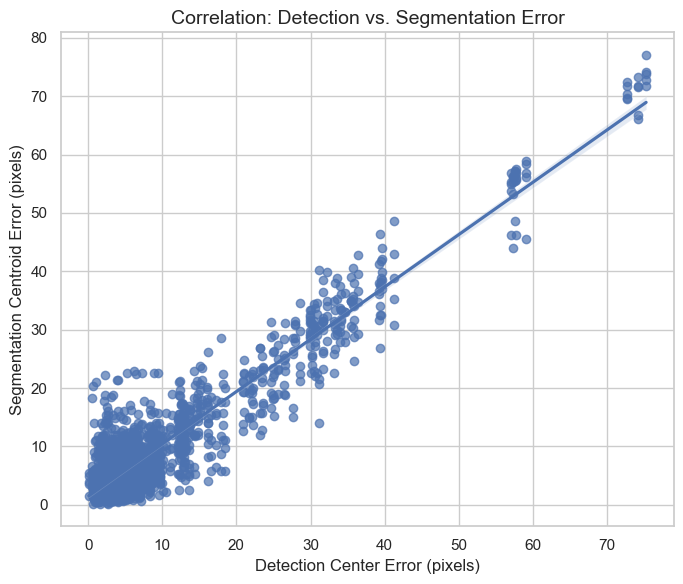

Pearson R : 0.9419 (p-value: 0.0000e+00)
Spearman R: 0.6694 (p-value: 4.0811e-273)


In [9]:
# Section 2: 相關性與迴歸線
if not MERGED_AVAILABLE or len(merged) < 2:
    print('Not enough merged data to compute correlation or plot regression.')
    pearson_r = pearson_p = spearman_r = spearman_p = math.nan
else:
    sns.set_theme(style='whitegrid')
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.regplot(data=merged, x='det_ce', y='seg_centroid', scatter_kws={'alpha': 0.7}, ax=ax)
    ax.set_xlabel('Detection Center Error (pixels)', fontsize=12)
    ax.set_ylabel('Segmentation Centroid Error (pixels)', fontsize=12)
    ax.set_title('Correlation: Detection vs. Segmentation Error', fontsize=14)
    plt.tight_layout()
    plt.show()
    pearson_r, pearson_p = stats.pearsonr(merged['det_ce'], merged['seg_centroid'])
    spearman_r, spearman_p = stats.spearmanr(merged['det_ce'], merged['seg_centroid'])
    print(f"Pearson R : {pearson_r:.4f} (p-value: {pearson_p:.4e})")
    print(f"Spearman R: {spearman_r:.4f} (p-value: {spearman_p:.4e})")

In [10]:
# Section 3: 質心誤差比較與配對檢定
merged['delta'] = merged['det_ce'] - merged['seg_centroid'] if MERGED_AVAILABLE else np.nan
if not MERGED_AVAILABLE or len(merged) < 2:
    print('Not enough merged data to run paired tests.')
    ttest_res = type('obj', (), {'pvalue': math.nan})()
    wilcoxon_res = type('obj', (), {'pvalue': math.nan})()
    summary_cmp = pd.DataFrame()
else:
    ttest_res = stats.ttest_rel(merged['det_ce'], merged['seg_centroid'])
    try:
        wilcoxon_res = stats.wilcoxon(merged['det_ce'], merged['seg_centroid'])
    except Exception as exc:
        wilcoxon_res = {'statistic': math.nan, 'pvalue': math.nan, 'error': str(exc)}
    summary_cmp = pd.DataFrame({
        'metric': ['mean', 'median', 'std', 'p25', 'p75'],
        'det_ce': [merged['det_ce'].mean(), merged['det_ce'].median(), merged['det_ce'].std(), merged['det_ce'].quantile(0.25), merged['det_ce'].quantile(0.75)],
        'seg_centroid': [merged['seg_centroid'].mean(), merged['seg_centroid'].median(), merged['seg_centroid'].std(), merged['seg_centroid'].quantile(0.25), merged['seg_centroid'].quantile(0.75)],
        'delta (det - seg)': [merged['delta'].mean(), merged['delta'].median(), merged['delta'].std(), merged['delta'].quantile(0.25), merged['delta'].quantile(0.75)],
    })
    print('Paired t-test p-value:', ttest_res.pvalue)
    print('Wilcoxon p-value:', getattr(wilcoxon_res, 'pvalue', wilcoxon_res))
summary_cmp

Paired t-test p-value: 3.609446761737699e-11
Wilcoxon p-value: 6.712187276651993e-11


,metric,det_ce,seg_centroid,delta (det - seg)
0,mean,8.826338,9.389061,-0.562723
1,median,4.751443,5.511042,-0.396658
2,std,11.535093,10.976234,3.874996
3,p25,2.680239,3.164551,-2.404389
4,p75,8.533441,10.463584,1.468309


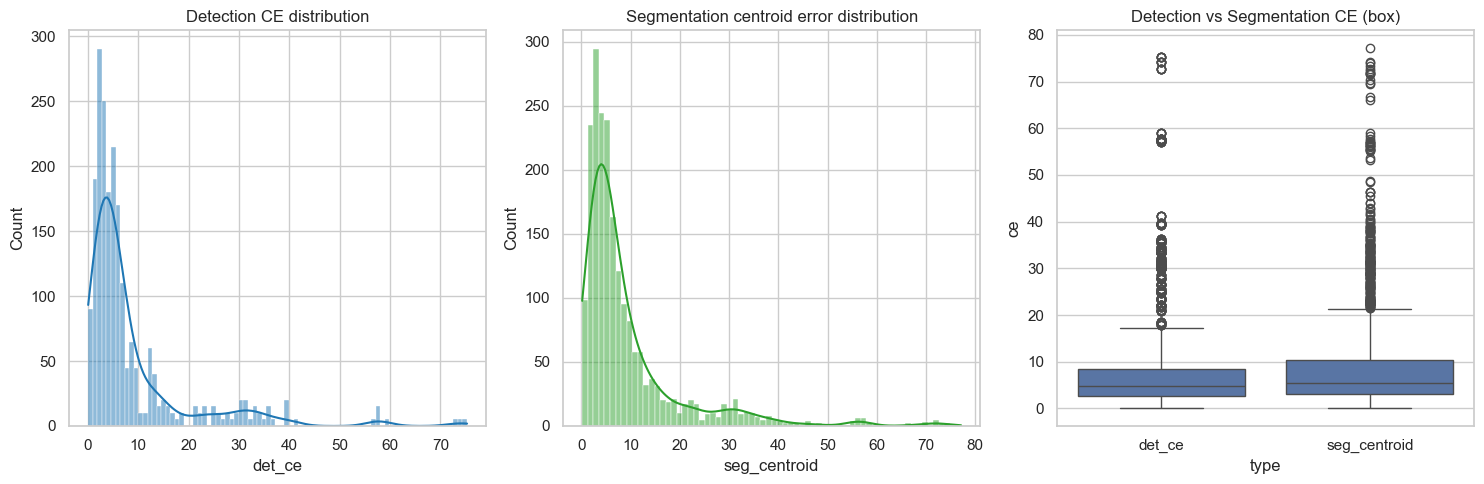

C:\Users\User\AppData\Local\Temp\ipykernel_12504\2571305049.py:22: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


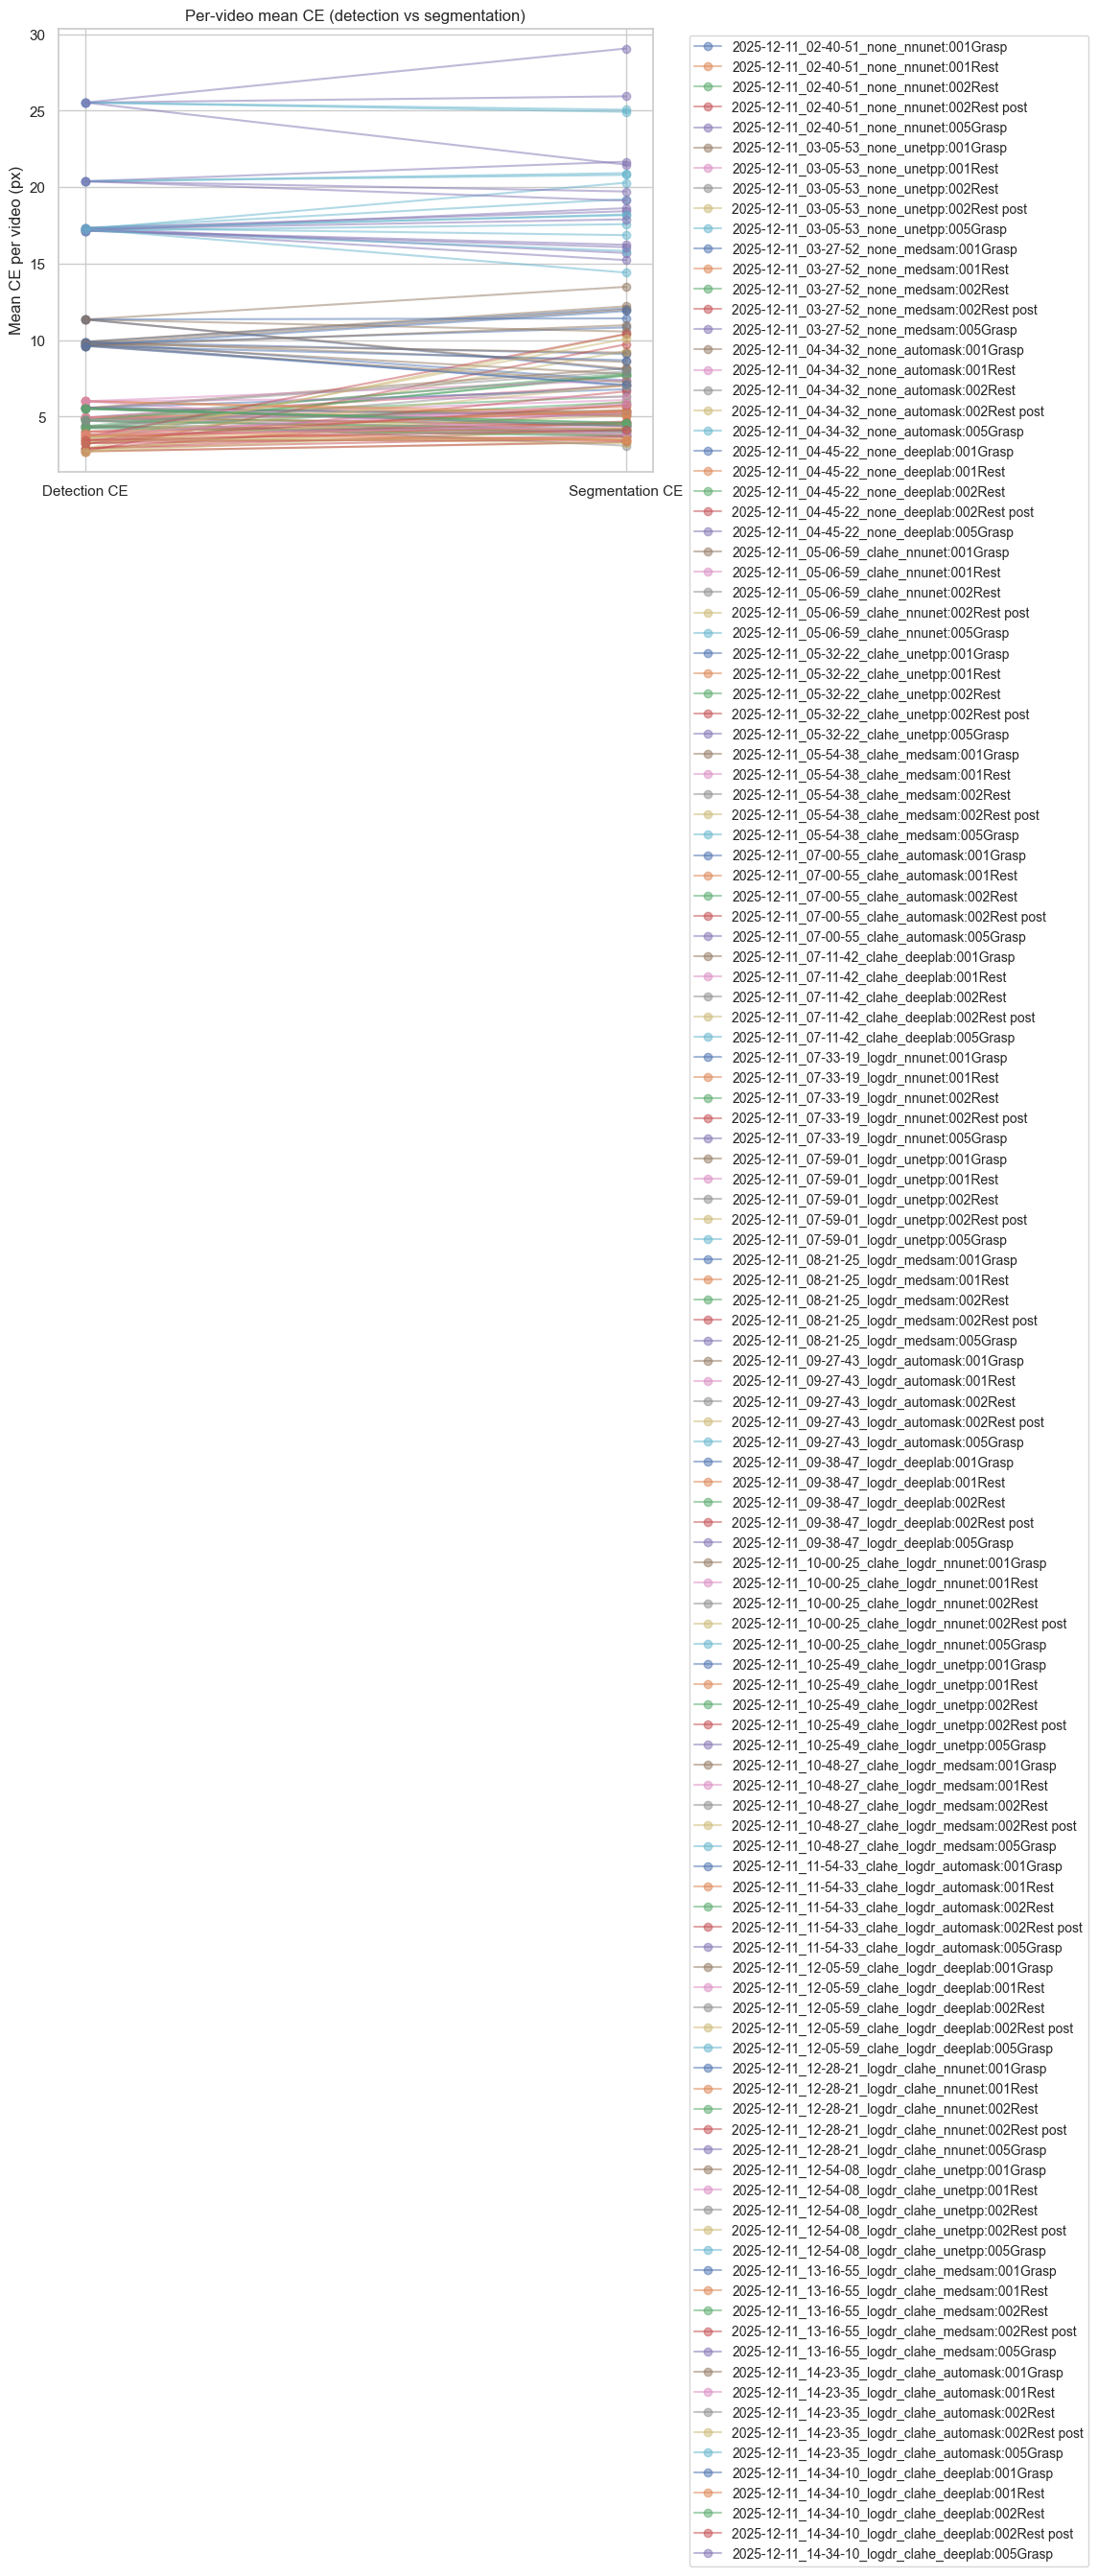

In [11]:
# Section 4: 視覺化誤差分佈與配對差異
if not MERGED_AVAILABLE:
    print('No merged data; skipping distribution and paired-difference plots.')
else:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    sns.histplot(merged['det_ce'], kde=True, ax=axes[0], color='#1f77b4')
    axes[0].set_title('Detection CE distribution')
    sns.histplot(merged['seg_centroid'], kde=True, ax=axes[1], color='#2ca02c')
    axes[1].set_title('Segmentation centroid error distribution')
    sns.boxplot(data=merged.melt(value_vars=['det_ce', 'seg_centroid'], var_name='type', value_name='ce'), x='type', y='ce', ax=axes[2])
    axes[2].set_title('Detection vs Segmentation CE (box)')
    plt.tight_layout()
    plt.show()
    plt.figure(figsize=(8, 6))
    merged['video_label'] = merged['experiment'] + ':' + merged['video']
    for vid_label, group in merged.groupby('video_label'):
        plt.plot([0, 1], [group['det_ce'].mean(), group['seg_centroid'].mean()], marker='o', alpha=0.5, label=vid_label)
    plt.xticks([0, 1], ['Detection CE', 'Segmentation CE'])
    plt.ylabel('Mean CE per video (px)')
    plt.title('Per-video mean CE (detection vs segmentation)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
    plt.tight_layout()
    plt.show()

In [12]:
# Section 5: 結論性摘要表
if not MERGED_AVAILABLE:
    report = {
        'n_frames': 0,
        'mean_det_ce': np.nan,
        'mean_seg_ce': np.nan,
        'median_det_ce': np.nan,
        'median_seg_ce': np.nan,
        'pearson_r': math.nan,
        'pearson_p': math.nan,
        'spearman_r': math.nan,
        'spearman_p': math.nan,
        'paired_t_p': math.nan,
        'wilcoxon_p': math.nan,
        'frac_seg_better': math.nan,
        'mean_delta_det_minus_seg': math.nan,
        'note': 'No segmentation metrics available; see earlier warnings.'
    }
else:
    report = {
        'n_frames': len(merged),
        'mean_det_ce': merged['det_ce'].mean(),
        'mean_seg_ce': merged['seg_centroid'].mean(),
        'median_det_ce': merged['det_ce'].median(),
        'median_seg_ce': merged['seg_centroid'].median(),
        'pearson_r': pearson_r,
        'pearson_p': pearson_p,
        'spearman_r': spearman_r,
        'spearman_p': spearman_p,
        'paired_t_p': ttest_res.pvalue,
        'wilcoxon_p': getattr(wilcoxon_res, 'pvalue', np.nan),
        'frac_seg_better': float((merged['delta'] > 0).mean()),
        'mean_delta_det_minus_seg': merged['delta'].mean(),
    }
pd.DataFrame([report])

,n_frames,mean_det_ce,mean_seg_ce,median_det_ce,median_seg_ce,pearson_r,pearson_p,spearman_r,spearman_p,paired_t_p,wilcoxon_p,frac_seg_better,mean_delta_det_minus_seg
0,2100,8.826338,9.389061,4.751443,5.511042,0.941936,0.0,0.669417,4.081070e-273,3.609447e-11,6.712187e-11,0.442857,-0.562723


## 使用說明
1. 依序執行各 cell；若缺少套件可在 notebook 內安裝（例如 `pip install seaborn scipy`）。
2. `merged` DataFrame 已含每個 video/frame 的 detection CE 與 segmentation centroid error，可再自訂視覺化。
3. 關注 `report` 與 `summary_cmp`：`mean_delta_det_minus_seg` > 0 且配對檢定 p-value 顯著，表示 segmentation 比 bbox 更能降低質心誤差。